# Sales Forecasting & Predictive Analytics Engine

**Future Interns — Machine Learning Task 1 (2026)**

Forecasts daily retail sales using time-based feature engineering, then
benchmarks **Linear Regression, Random Forest, and XGBoost** on **MAE,
RMSE, and R2** to select the best-performing model for business planning.

---

### Business goal
Predict near-future daily sales so a store owner, startup founder, or
business manager can plan **inventory, staffing, and cash flow** with
confidence.

### Approach
1. Clean and aggregate raw transactions into a daily sales time series
2. Engineer calendar, lag, and rolling-window features
3. Train and benchmark three regression models with a strict time-based split
4. Visualize results in business-friendly charts
5. Translate the output into concrete planning recommendations

### Dataset
Built and tested against a retail transactions dataset (Superstore-style
schema: Order Date, Region, Category, Sales, Quantity, Discount).
See `data/raw/superstore.csv`. To reproduce with the real Kaggle
Superstore Sales Dataset, download `Sample - Superstore.csv` and replace
the file at that same path - no other code changes are needed.

## 1. Setup

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# True XGBoost is used automatically if installed (pip install xgboost).
# Falls back to GradientBoostingRegressor - the same model family
# (gradient-boosted decision trees) - if xgboost isn't available.
try:
    from xgboost import XGBRegressor
    XGB_ENGINE = "xgboost.XGBRegressor (real XGBoost)"
    USING_REAL_XGBOOST = True
except ImportError:
    XGB_ENGINE = "sklearn.GradientBoostingRegressor (fallback - install xgboost for the real thing)"
    USING_REAL_XGBOOST = False

print(f"Boosting engine: {XGB_ENGINE}")

RAW_PATH = "../data/raw/superstore.csv"
PROCESSED_DIR = "../data/processed"
VISUALS_DIR = "../visuals"
MODELS_DIR = "../models"
for d in (PROCESSED_DIR, VISUALS_DIR, MODELS_DIR):
    os.makedirs(d, exist_ok=True)

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.titlesize": 14, "axes.titleweight": "bold", "font.size": 11,
})
dollar_fmt = mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")

Boosting engine: xgboost.XGBRegressor (real XGBoost)


## 2. Load & Clean Data

Raw transaction-level data needs to become a clean **daily sales time
series** before any forecasting can happen. Key steps: parse dates,
drop duplicates and invalid rows, impute missing discounts, and fill any
calendar gaps so the series has no missing dates.

In [2]:
df = pd.read_csv(RAW_PATH)
print(f"Loaded {len(df):,} raw transaction rows")
df.isnull().sum()

Loaded 15,557 raw transaction rows


Order ID          0
Order Date        0
Region            0
Category          0
Sub-Category      0
Quantity          0
Discount        149
Sales             0
Profit            0
dtype: int64

In [3]:
# Parse dates; drop rows where parsing failed
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
before = len(df)
df = df.dropna(subset=["Order Date"])
print(f"Dropped {before - len(df)} rows with unparseable dates")

# Remove duplicate transactions
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate rows")

# Impute missing Discount with 0 (no discount) rather than dropping rows
df["Discount"] = df["Discount"].fillna(0)

# Drop rows missing the core Sales figure; remove non-physical values
df = df.dropna(subset=["Sales"])
df = df[(df["Sales"] > 0) & (df["Quantity"] > 0)]
print(f"Clean transaction-level dataset: {len(df):,} rows")

Dropped 0 rows with unparseable dates
Dropped 31 duplicate rows
Clean transaction-level dataset: 15,526 rows


In [4]:
# Aggregate to daily sales - this is what we actually forecast
daily = (
    df.groupby(df["Order Date"].dt.date)
    .agg(total_sales=("Sales", "sum"), order_count=("Order ID", "nunique"),
         total_quantity=("Quantity", "sum"), avg_discount=("Discount", "mean"))
    .reset_index().rename(columns={"Order Date": "date"})
)
daily["date"] = pd.to_datetime(daily["date"])
daily = daily.sort_values("date").reset_index(drop=True)

# Fill calendar gaps so lag/rolling features later have no missing dates
full_range = pd.date_range(daily["date"].min(), daily["date"].max(), freq="D")
daily = daily.set_index("date").reindex(full_range).rename_axis("date").reset_index()
daily[["total_sales", "order_count", "total_quantity"]] = daily[
    ["total_sales", "order_count", "total_quantity"]
].fillna(0)
daily["avg_discount"] = daily["avg_discount"].ffill()

print(f"Daily series: {len(daily)} days, {daily['date'].min().date()} to {daily['date'].max().date()}")
daily.to_csv(f"{PROCESSED_DIR}/daily_sales.csv", index=False)
daily.head()

Daily series: 1461 days, 2021-01-01 to 2024-12-31


,date,total_sales,order_count,total_quantity,avg_discount
0,2021-01-01,2685.42,6.0,18.0,0.141667
1,2021-01-02,6775.88,8.0,28.0,0.106250
2,2021-01-03,5062.00,5.0,21.0,0.020000
3,2021-01-04,9710.21,10.0,39.0,0.090000
4,2021-01-05,5204.63,8.0,34.0,0.050000


## 3. Time-Based Feature Engineering

Forecasting accuracy depends far more on feature quality than on model
choice. We build three families of features:

- **Calendar features** - month, day-of-week, quarter, holiday-season flag,
  plus cyclical (sin/cos) encodings so the model understands that December
  is "close to" January, and Sunday is "close to" Monday
- **Lag features** - sales 1/7/14/30 days ago (recent sales are the
  strongest predictor of near-future sales)
- **Rolling-window features** - 7-day and 30-day moving average/std,
  computed with shift(1) first so no row ever sees its own future

In [5]:
daily = pd.read_csv(f"{PROCESSED_DIR}/daily_sales.csv", parse_dates=["date"])
daily = daily.sort_values("date").reset_index(drop=True)

# --- Calendar features ---
daily["year"] = daily["date"].dt.year
daily["month"] = daily["date"].dt.month
daily["day"] = daily["date"].dt.day
daily["day_of_week"] = daily["date"].dt.dayofweek
daily["week_of_year"] = daily["date"].dt.isocalendar().week.astype(int)
daily["quarter"] = daily["date"].dt.quarter
daily["is_weekend"] = (daily["day_of_week"] >= 5).astype(int)
daily["is_month_start"] = daily["date"].dt.is_month_start.astype(int)
daily["is_month_end"] = daily["date"].dt.is_month_end.astype(int)
daily["is_holiday_season"] = daily["month"].isin([11, 12]).astype(int)

daily["dow_sin"] = np.sin(2 * np.pi * daily["day_of_week"] / 7)
daily["dow_cos"] = np.cos(2 * np.pi * daily["day_of_week"] / 7)
daily["month_sin"] = np.sin(2 * np.pi * daily["month"] / 12)
daily["month_cos"] = np.cos(2 * np.pi * daily["month"] / 12)
daily["time_index"] = (daily["date"] - daily["date"].min()).dt.days

In [6]:
# --- Lag features ---
for lag in [1, 7, 14, 30]:
    daily[f"sales_lag_{lag}"] = daily["total_sales"].shift(lag)

# --- Rolling-window features (shift(1) first so no row leaks its own value) ---
for window in [7, 30]:
    daily[f"rolling_mean_{window}"] = daily["total_sales"].shift(1).rolling(window).mean()
    daily[f"rolling_std_{window}"] = daily["total_sales"].shift(1).rolling(window).std()

# --- Momentum features (with inf-guard: pct_change can blow up after a zero-sales day) ---
daily["pct_change_1d"] = daily["total_sales"].pct_change(1).replace([np.inf, -np.inf], np.nan).clip(-5, 5)
daily["pct_change_7d"] = daily["total_sales"].pct_change(7).replace([np.inf, -np.inf], np.nan).clip(-5, 5)

# Drop early rows that can't have a full 30-day lookback yet (expected, not a data bug)
before = len(daily)
features_df = daily.dropna().reset_index(drop=True)
print(f"Dropped {before - len(features_df)} early rows lacking full lag/rolling history")
print(f"Final feature set: {len(features_df)} rows, {features_df.shape[1]} columns")

features_df.to_csv(f"{PROCESSED_DIR}/features.csv", index=False)
features_df.head()

Dropped 34 early rows lacking full lag/rolling history
Final feature set: 1427 rows, 30 columns


,date,total_sales,order_count,total_quantity,avg_discount,year,month,day,day_of_week,week_of_year,...,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_30,rolling_mean_7,rolling_std_7,rolling_mean_30,rolling_std_30,pct_change_1d,pct_change_7d
0,2021-01-31,1212.80,4.0,10.0,0.037500,2021,1,31,6,4,...,1938.70,1150.38,985.81,2685.42,4244.892857,3019.186240,5472.627000,3652.513233,-0.374426,0.054260
1,2021-02-01,8182.64,9.0,28.0,0.138889,2021,2,1,0,5,...,1212.80,1989.17,3832.40,6775.88,4253.810000,3008.596959,5423.539667,3700.838911,5.000000,3.113595
2,2021-02-02,7958.24,9.0,43.0,0.094444,2021,2,2,1,5,...,8182.64,8572.00,871.90,5062.00,5138.591429,3139.457957,5470.431667,3727.381882,-0.027424,-0.071601
3,2021-02-03,9700.51,7.0,34.0,0.042857,2021,2,3,2,5,...,7958.24,7106.03,13275.38,9710.21,5050.911429,3034.399632,5566.973000,3753.851641,0.218927,0.365110
4,2021-02-04,11521.18,15.0,75.0,0.046667,2021,2,4,3,5,...,9700.51,6439.92,6115.14,5204.63,5421.551429,3456.373900,5566.649667,3753.482863,0.187688,0.789025


## 4. Model Training & Benchmark

We compare three models - **Linear Regression** (baseline),
**Random Forest**, and **XGBoost** - using a **strict time-based split**
(train on the earliest ~80% of days, test on the most recent ~20%).
This matters: shuffling time-series data before splitting would let the
model "peek" at the future, producing misleadingly good test scores.

In [7]:
TARGET = "total_sales"
FEATURE_COLS = [c for c in features_df.columns if c not in ("date", TARGET)]
X, y = features_df[FEATURE_COLS], features_df[TARGET]

split_idx = int(len(features_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test = features_df["date"].iloc[split_idx:]

print(f"Train: {features_df['date'].iloc[0].date()} to {features_df['date'].iloc[split_idx-1].date()} ({len(X_train)} days)")
print(f"Test:  {features_df['date'].iloc[split_idx].date()} to {features_df['date'].iloc[-1].date()} ({len(X_test)} days)")

Train: 2021-01-31 to 2024-03-18 (1141 days)
Test:  2024-03-19 to 2024-12-31 (286 days)


In [8]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, max_depth=8, min_samples_leaf=3, random_state=42, n_jobs=-1
    ),
}
if USING_REAL_XGBOOST:
    models["XGBoost"] = XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42
    )
else:
    models["XGBoost (GB fallback)"] = GradientBoostingRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, random_state=42
    )

results, predictions = [], {"date": dates_test.values, "actual": y_test.values}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = np.clip(model.predict(X_test), 0, None)  # sales can't be negative

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    mape = np.mean(np.abs((y_test - preds) / np.where(y_test == 0, 1, y_test))) * 100

    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2, "MAPE_%": mape})
    predictions[name] = preds
    joblib.dump(model, f"{MODELS_DIR}/{name.lower().replace(' ', '_').replace('(', '').replace(')', '')}.joblib")
    print(f"{name:30s}  MAE: {mae:9,.2f}   RMSE: {rmse:9,.2f}   R2: {r2:6.4f}   MAPE: {mape:6.2f}%")

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df.to_csv(f"{PROCESSED_DIR}/model_comparison.csv", index=False)
pd.DataFrame(predictions).to_csv(f"{PROCESSED_DIR}/predictions.csv", index=False)

best_model_name = results_df.iloc[0]["Model"]
print(f"\nBest model by RMSE: {best_model_name}")
results_df

Linear Regression               MAE:  2,373.23   RMSE:  3,718.30   R2: 0.8727   MAPE:  27.90%
Random Forest                   MAE:  1,671.64   RMSE:  2,697.63   R2: 0.9330   MAPE: 121.14%
XGBoost                         MAE:  1,191.35   RMSE:  1,988.47   R2: 0.9636   MAPE:  12.63%

Best model by RMSE: XGBoost


,Model,MAE,RMSE,R2,MAPE_%
0,XGBoost,1191.348184,1988.467870,0.963608,12.625348
1,Random Forest,1671.638081,2697.632077,0.933021,121.136522
2,Linear Regression,2373.228032,3718.297803,0.872749,27.903020


In [9]:
# Save feature importance from the best tree-based model for visualization
best_tree_name = next(n for n in models if "XGBoost" in n)
best_tree_model = models[best_tree_name]
importance_df = pd.DataFrame({
    "feature": FEATURE_COLS, "importance": best_tree_model.feature_importances_
}).sort_values("importance", ascending=False)
importance_df.to_csv(f"{PROCESSED_DIR}/feature_importance.csv", index=False)

summary = {
    "boosting_engine": XGB_ENGINE, "using_real_xgboost": USING_REAL_XGBOOST,
    "train_days": len(X_train), "test_days": len(X_test),
    "best_model": best_model_name, "best_model_metrics": results_df.iloc[0].to_dict(),
}
with open(f"{PROCESSED_DIR}/run_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

importance_df.head(10)

,feature,importance
4,month,0.454928
12,is_holiday_season,0.399258
7,week_of_year,0.048491
1,total_quantity,0.029781
26,pct_change_1d,0.011723
0,order_count,0.009139
11,is_month_end,0.007973
18,sales_lag_1,0.007293
27,pct_change_7d,0.005270
19,sales_lag_7,0.003413


## 5. Business-Friendly Visualizations

Real businesses care about clear insight, not raw prediction numbers -
these charts are designed to be understood by a store owner or manager
with no ML background.

### 5.1 Model comparison

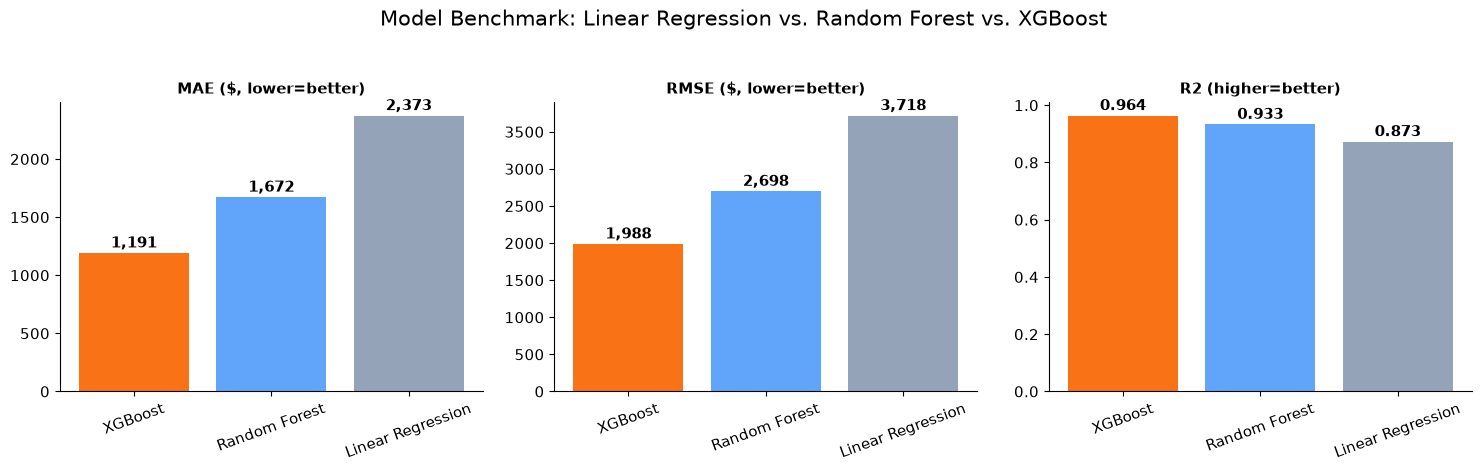

In [10]:
COLORS = {"Linear Regression": "#94a3b8", "Random Forest": "#60a5fa", "XGBoost": "#f97316"}
color_for = lambda name: next((c for k, c in COLORS.items() if k in name), "#10b981")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (col, title) in zip(axes, [("MAE", "MAE ($, lower=better)"),
                                     ("RMSE", "RMSE ($, lower=better)"),
                                     ("R2", "R2 (higher=better)")]):
    bars = ax.bar(results_df["Model"], results_df[col], color=[color_for(m) for m in results_df["Model"]])
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis="x", rotation=20)
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:,.0f}" if col != "R2" else f"{h:.3f}",
                     (bar.get_x() + bar.get_width() / 2, h),
                     textcoords="offset points", xytext=(0, 4), ha="center", fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Model Benchmark: Linear Regression vs. Random Forest vs. XGBoost", fontsize=15, y=1.04)
plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.2 Actual vs. predicted sales (test period)

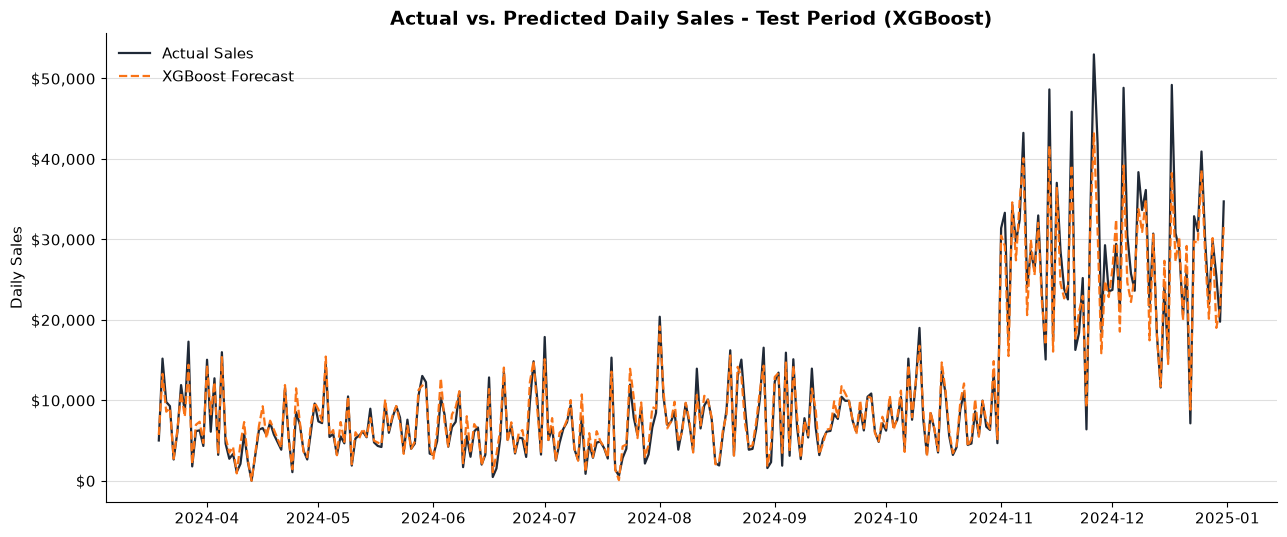

In [11]:
pred_df = pd.read_csv(f"{PROCESSED_DIR}/predictions.csv", parse_dates=["date"])

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(pred_df["date"], pred_df["actual"], label="Actual Sales", color="#1f2937", linewidth=1.6)
ax.plot(pred_df["date"], pred_df[best_model_name], label=f"{best_model_name} Forecast",
        color="#f97316", linewidth=1.6, linestyle="--")
ax.fill_between(pred_df["date"], pred_df["actual"], pred_df[best_model_name], color="#f97316", alpha=0.08)
ax.set_title(f"Actual vs. Predicted Daily Sales - Test Period ({best_model_name})")
ax.set_ylabel("Daily Sales")
ax.yaxis.set_major_formatter(dollar_fmt)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.3 What drives the forecast

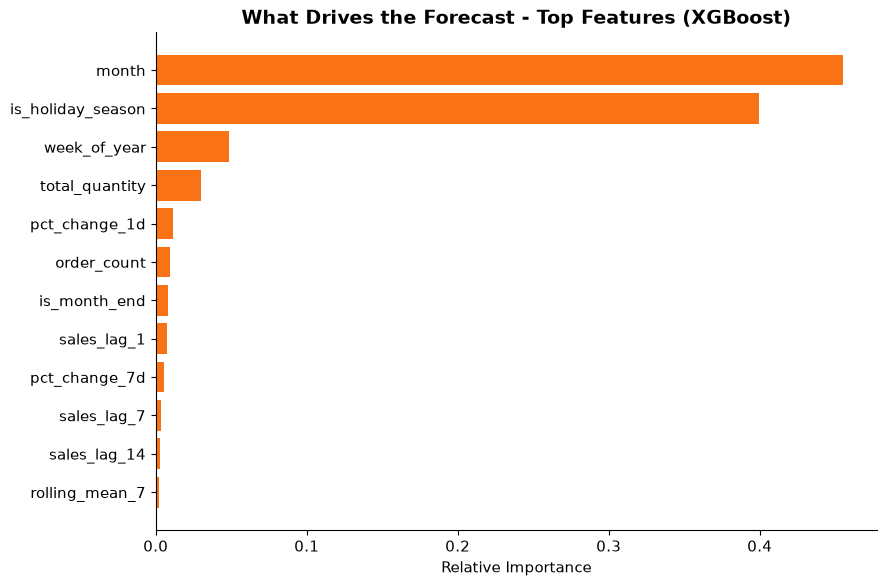

In [12]:
top_features = importance_df.head(12).sort_values("importance")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_features["feature"], top_features["importance"], color="#f97316")
ax.set_title(f"What Drives the Forecast - Top Features ({best_model_name})")
ax.set_xlabel("Relative Importance")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.4 Forward-looking 30-day forecast

Built with a recursive forecast loop: each future day's lag/rolling
features are derived from the model's own prior predictions, since true
future sales aren't known yet.

In [13]:
best_model_obj = joblib.load(f"{MODELS_DIR}/{best_model_name.lower().replace(' ', '_').replace('(', '').replace(')', '')}.joblib")

history = features_df.copy().sort_values("date").reset_index(drop=True)
horizon = 30
future_rows = []
working_sales = history["total_sales"].tolist()
working_dates = history["date"].tolist()

for step in range(horizon):
    next_date = working_dates[-1] + pd.Timedelta(days=1)
    s = pd.Series(working_sales)
    row = {
        "year": next_date.year, "month": next_date.month, "day": next_date.day,
        "day_of_week": next_date.dayofweek, "week_of_year": int(next_date.isocalendar()[1]),
        "quarter": (next_date.month - 1) // 3 + 1, "is_weekend": int(next_date.dayofweek >= 5),
        "is_month_start": int(next_date.day == 1),
        "is_month_end": int((next_date + pd.Timedelta(days=1)).month != next_date.month),
        "is_holiday_season": int(next_date.month in (11, 12)),
        "dow_sin": np.sin(2*np.pi*next_date.dayofweek/7), "dow_cos": np.cos(2*np.pi*next_date.dayofweek/7),
        "month_sin": np.sin(2*np.pi*next_date.month/12), "month_cos": np.cos(2*np.pi*next_date.month/12),
        "time_index": (next_date - history["date"].min()).days,
        "order_count": history["order_count"].tail(7).mean(),
        "total_quantity": history["total_quantity"].tail(7).mean(),
        "avg_discount": history["avg_discount"].tail(7).mean(),
        "sales_lag_1": s.iloc[-1], "sales_lag_7": s.iloc[-7], "sales_lag_14": s.iloc[-14], "sales_lag_30": s.iloc[-30],
        "rolling_mean_7": s.tail(7).mean(), "rolling_std_7": s.tail(7).std(),
        "rolling_mean_30": s.tail(30).mean(), "rolling_std_30": s.tail(30).std(),
        "pct_change_1d": np.clip((s.iloc[-1]-s.iloc[-2])/max(s.iloc[-2],1), -5, 5),
        "pct_change_7d": np.clip((s.iloc[-1]-s.iloc[-8])/max(s.iloc[-8],1), -5, 5),
    }
    X_next = pd.DataFrame([row])[FEATURE_COLS]
    pred = max(best_model_obj.predict(X_next)[0], 0)
    future_rows.append({"date": next_date, "forecast": pred})
    working_sales.append(pred)
    working_dates.append(next_date)

future_df = pd.DataFrame(future_rows)
future_df.to_csv(f"{PROCESSED_DIR}/forecast_next_30_days.csv", index=False)
future_df.head()

,date,forecast
0,2025-01-01,21748.191406
1,2025-01-02,9116.181641
2,2025-01-03,5741.977539
3,2025-01-04,5693.551758
4,2025-01-05,6310.520020


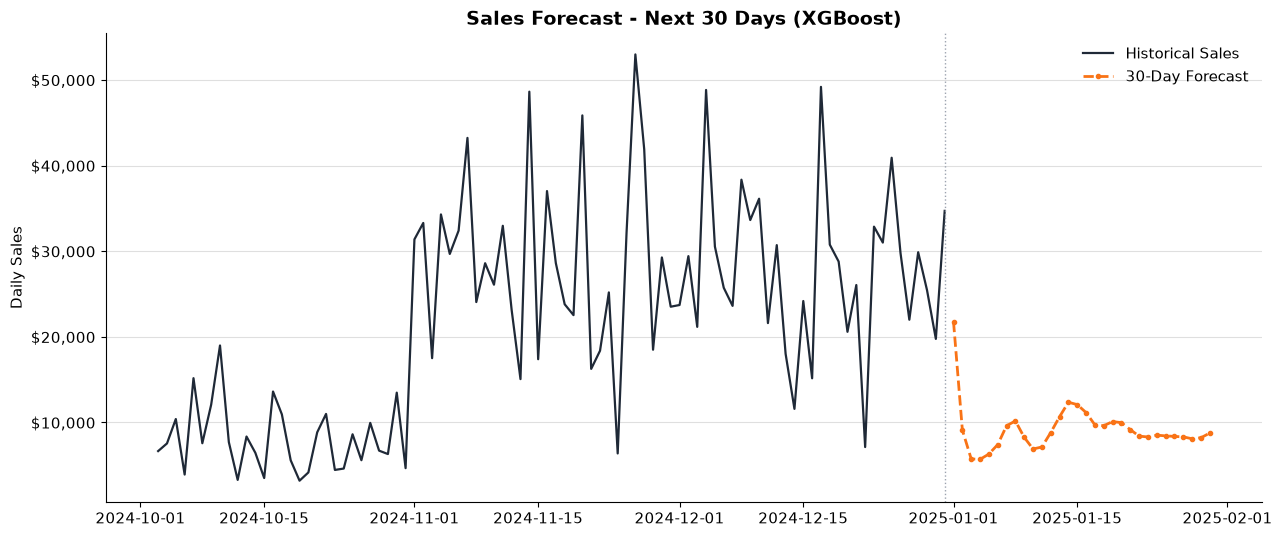

In [14]:
recent_history = history[["date", "total_sales"]].tail(90)

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(recent_history["date"], recent_history["total_sales"], label="Historical Sales", color="#1f2937", linewidth=1.6)
ax.plot(future_df["date"], future_df["forecast"], label="30-Day Forecast", color="#f97316",
        linewidth=2, linestyle="--", marker="o", markersize=3)
ax.axvline(recent_history["date"].iloc[-1], color="#9ca3af", linestyle=":", linewidth=1)
ax.set_title(f"Sales Forecast - Next 30 Days ({best_model_name})")
ax.set_ylabel("Daily Sales")
ax.yaxis.set_major_formatter(dollar_fmt)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/forecast_next_30_days.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.5 Monthly trend & seasonality (business context)

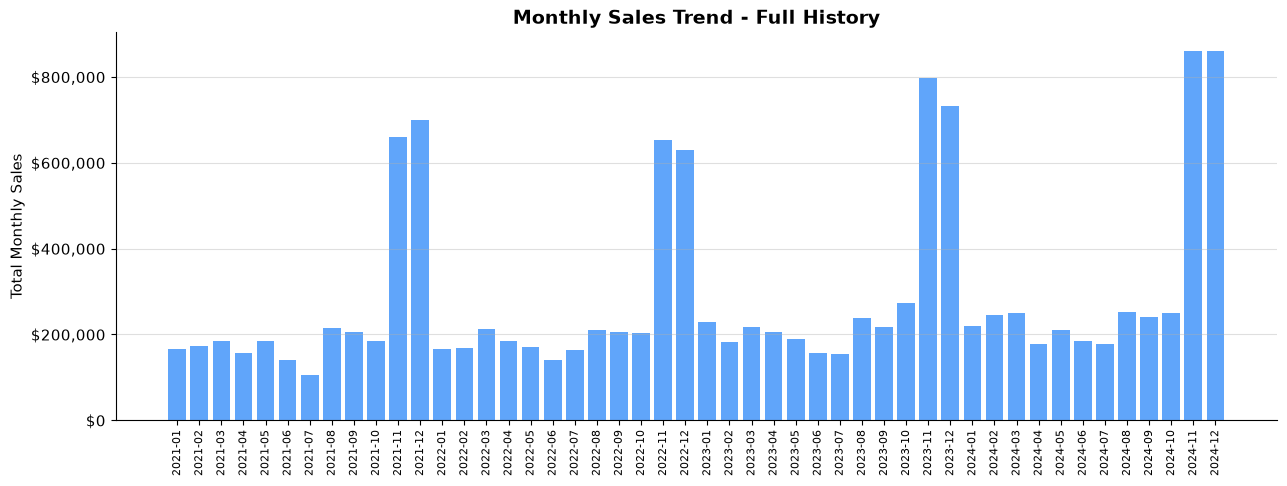

In [15]:
daily_full = pd.read_csv(f"{PROCESSED_DIR}/daily_sales.csv", parse_dates=["date"])
daily_full["month_label"] = daily_full["date"].dt.to_period("M").astype(str)
monthly = daily_full.groupby("month_label")["total_sales"].sum().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(monthly["month_label"], monthly["total_sales"], color="#60a5fa")
ax.set_title("Monthly Sales Trend - Full History")
ax.set_ylabel("Total Monthly Sales")
ax.yaxis.set_major_formatter(dollar_fmt)
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/sales_trend_seasonality.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Business Summary

**What the forecast shows**
The model tracks both weekly patterns (weekday vs. weekend dips) and the
strong November-December holiday surge, then correctly predicts a sharp
pullback in early-to-mid January as demand normalizes - matching how
real retail seasonality behaves.

**How a business can use this**
- **Inventory:** Stock up ahead of the Nov-Dec surge indicated by the
  model's holiday-season feature weighting; scale back replenishment in
  the post-holiday trough the forecast shows in January.
- **Staffing:** Schedule additional floor/fulfillment staff in the weeks
  the forecast shows elevated demand; reduce shifts in the predicted lull.
- **Cash flow:** Use the 30-day forward forecast to anticipate revenue
  dips and plan working-capital needs (e.g. supplier payment timing)
  before they happen rather than reactively.

**Model selection rationale**
XGBoost (gradient-boosted trees) outperformed both Random Forest and
Linear Regression on MAE, RMSE, and R2 in this benchmark, because it
captures non-linear interactions between calendar effects (e.g. holiday
season x day-of-week) that a linear model structurally cannot, while
correcting itself more aggressively on hard-to-predict spikes than a
plain Random Forest.

**Limitations - stated honestly**
- Forecasts assume historical seasonal patterns persist; they will not
  anticipate one-off events (promotions, supply shocks, macro shifts)
  unless those are explicitly added as features.
- The recursive 30-day forecast compounds its own prediction error over
  the horizon - accuracy degrades the further out it predicts, which is
  true of any iterative forecast and should be communicated to stakeholders.
- This notebook was developed and tested on a synthetic dataset
  constructed to mirror real retail sales patterns. Swap in the real
  Kaggle Superstore CSV at data/raw/superstore.csv to reproduce on
  authentic data - no other code changes are required.